# Creator specialization rate: the 90% headline, properly checked

**Purpose**: dedicated home for the "90% of creators stream exactly one title" finding, which has become the centerpiece claim for `research/foundations/posts/post_3_anatomy_of_a_network/` (see that brief and the research journal, 2026-09-21 second entry) -- previously a side observation inside `creator_crossover_null_model_test.ipynb`, now load-bearing enough to need its own robustness checks rather than being cited as a flat, unqualified number.

**What this notebook actually tests**: not just "what is the number," but "is the number real, or partly an artifact of this project's own short observation window" -- the same family of concern `creator_current_tenure_by_title.ipynb` raised for account-creation timing (confound #3, survivorship bias from a 3-week collector). The concern here is structurally similar but distinct: a channel that genuinely streams two titles but happens to have only been observed once or twice by this collector has no real chance of having *both* titles caught. If that's a large effect, the 90% figure partly measures "how much of the population we've barely observed," not "how specialized creators actually are."

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import pearsonr, spearmanr

from etl.db import get_connection

In [2]:
# Full (channel, title, captured_at) grain -- not deduplicated to
# (channel, title) yet, since the robustness check below needs to count
# how many distinct snapshots each channel was actually observed in.
conn = get_connection()
full = pd.DataFrame(conn.execute(
    "SELECT channel_id, title_id, captured_at FROM viewership_snapshots WHERE is_official_broadcast = 0"
).fetchall(), columns=["channel_id", "title_id", "captured_at"])
n_snapshot_dates = conn.execute("SELECT COUNT(DISTINCT captured_at) FROM viewership_snapshots").fetchone()[0]
conn.close()

print(f"{len(full):,} (channel, title, snapshot) rows")
print(f"{full['channel_id'].nunique():,} distinct channels")
print(f"{n_snapshot_dates} distinct collector snapshots total -- the full extent of this project's observation window")

1,233,950 (channel, title, snapshot) rows
296,583 distinct channels
180 distinct collector snapshots total -- the full extent of this project's observation window


In [3]:
# The headline number, computed cleanly: distinct titles observed per
# channel, across the channel's entire history in this dataset.
titles_per_channel = full.groupby("channel_id")["title_id"].nunique().rename("n_titles")

print("Distribution of distinct titles streamed, per channel:")
print(titles_per_channel.value_counts().sort_index().to_string())

pct_single = (titles_per_channel == 1).mean() * 100
print(f"\n% of channels that stream exactly one tracked title: {pct_single:.2f}%")
print(f"mean titles per channel: {titles_per_channel.mean():.3f}")

Distribution of distinct titles streamed, per channel:
n_titles
1    263351
2     28122
3      4346
4       645
5       106
6        11
7         2

% of channels that stream exactly one tracked title: 88.80%
mean titles per channel: 1.132


## Does the rate vary meaningfully by title?

"Of channels that stream title X at all, what % stream *only* X" -- a per-title conditional rate, not the same quantity as the population-wide headline above (a channel that streams two titles counts against *both* titles' rates here, so these will generally read lower than 90%, and that's expected, not an error).

In [4]:
vt = full.drop_duplicates(subset=["channel_id", "title_id"])[["channel_id", "title_id"]]
vt = vt.merge(titles_per_channel, on="channel_id")

per_title = vt.groupby("title_id")["n_titles"].apply(lambda s: (s == 1).mean() * 100).round(1)
n_channels = vt.groupby("title_id")["channel_id"].nunique()

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

per_title_df = pd.DataFrame({"pct_single_title": per_title, "n_channels": n_channels})
per_title_df["title"] = per_title_df.index.map(display_name_by_id)
per_title_df = per_title_df.sort_values("pct_single_title")
per_title_df[["title", "pct_single_title", "n_channels"]]

,title,pct_single_title,n_channels
title_id,,,
teamfight_tactics,Teamfight Tactics,49.5,6025
rocket_league,Rocket League,75.0,16125
league_of_legends,League of Legends,75.1,38518
pubg,PUBG: BATTLEGROUNDS,75.5,7568
valorant,VALORANT,75.5,61398
overwatch,Overwatch,75.7,35808
hearthstone,Hearthstone,76.7,1883
apex_legends,Apex Legends,77.1,28291
street_fighter,Street Fighter 6,78.6,4397


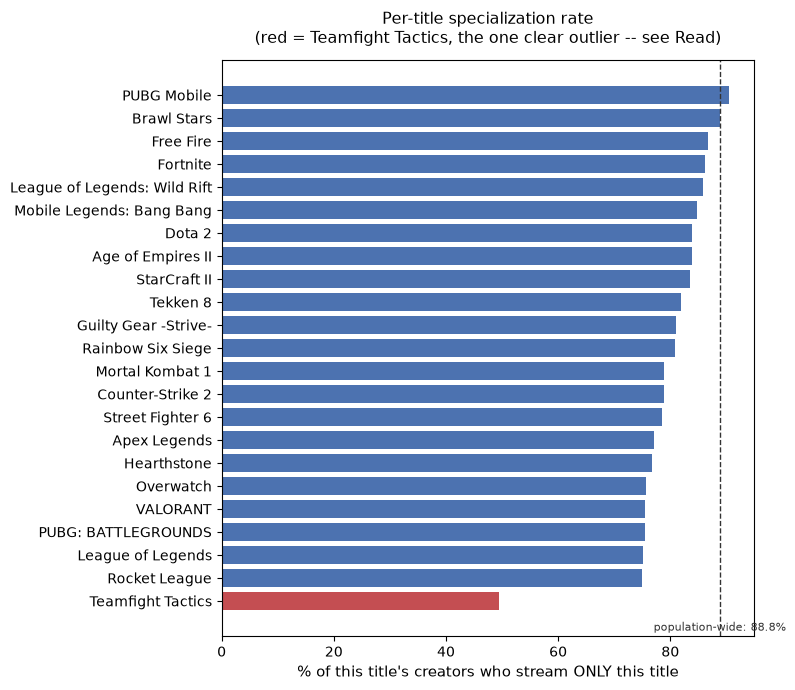

In [5]:
fig, ax = plt.subplots(figsize=(8, 7))
colors = ["#C44E52" if t == "teamfight_tactics" else "#4C72B0" for t in per_title_df.index]
ax.barh(per_title_df["title"], per_title_df["pct_single_title"], color=colors)
ax.axvline(pct_single, color="#333333", linewidth=1, linestyle="--")
ax.text(pct_single, -1.3, f"population-wide: {pct_single:.1f}%", fontsize=8, ha="center", color="#333333")
ax.set_xlabel("% of this title's creators who stream ONLY this title", fontsize=10.5)
ax.set_title("Per-title specialization rate\n(red = Teamfight Tactics, the one clear outlier -- see Read)", fontsize=11.5, pad=12)
plt.tight_layout()
plt.savefig(Path.cwd() / "_specialization_fig1_per_title.png", dpi=200, bbox_inches="tight")
plt.show()

## The real robustness check: does the rate depend on how much we've actually seen of each channel?

If a channel streams two titles but this collector has only caught it once or twice, there's essentially no chance of having observed both -- it will read as "single-title" for a reason that has nothing to do with how it actually behaves. Tested directly: does `n_titles` (distinct titles observed) correlate with `n_snapshots` (how many of this project's 120 total collector snapshots caught the channel at all)?

In [6]:
exposure = full.groupby("channel_id").agg(
    n_snapshots=("captured_at", "nunique"),
    n_titles=("title_id", "nunique"),
).reset_index()

print(f"Distribution of n_snapshots (how many of the {full['captured_at'].nunique()} total collector snapshots caught each channel):")
print(exposure["n_snapshots"].describe().to_string())

r, p = pearsonr(exposure["n_snapshots"], exposure["n_titles"])
rho, ps = spearmanr(exposure["n_snapshots"], exposure["n_titles"])
print(f"\nn_snapshots vs. n_titles: Pearson r={r:.3f} (p={p:.2e}), Spearman rho={rho:.3f} (p={ps:.2e})")

Distribution of n_snapshots (how many of the 180 total collector snapshots caught each channel):
count    296583.000000
mean          4.160555
std           6.939062
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         180.000000

n_snapshots vs. n_titles: Pearson r=0.234 (p=0.00e+00), Spearman rho=0.369 (p=0.00e+00)


In [7]:
# Finer bins toward the low-exposure end, where most of the population
# actually sits (median n_snapshots is 2) -- a coarse decile split would
# bury the real shape of this relationship inside its first bin. Top edge
# is the actual current snapshot count, not a hardcoded 120 -- caught on
# the 2026-10-02 re-run: the collector has since produced more than 120
# total snapshots, and a hardcoded 120 edge was silently dropping every
# channel observed more than 120 times into an uncounted NaN bin (74
# channels affected this run) -- exactly the highest-exposure population
# the Read section's own 'recovery at the high end' claim depends on.
bins = [0, 1, 2, 3, 5, 8, 12, 20, 40, full["captured_at"].nunique()]
exposure["exposure_bin"] = pd.cut(exposure["n_snapshots"], bins)
exposure_grp = exposure.groupby("exposure_bin", observed=True).agg(
    pct_single=("n_titles", lambda s: (s == 1).mean() * 100),
    mean_titles=("n_titles", "mean"),
    n_channels=("channel_id", "count"),
).round(2)
exposure_grp

,pct_single,mean_titles,n_channels
exposure_bin,,,
"(0, 1]",100.00,1.00,139206
"(1, 2]",87.47,1.13,47205
"(2, 3]",81.52,1.20,25321
"(3, 5]",77.04,1.26,27693
"(5, 8]",73.01,1.33,20681
"(8, 12]",71.06,1.37,14104
"(12, 20]",69.28,1.40,12735
"(20, 40]",71.08,1.39,7983
"(40, 180]",76.07,1.32,1655


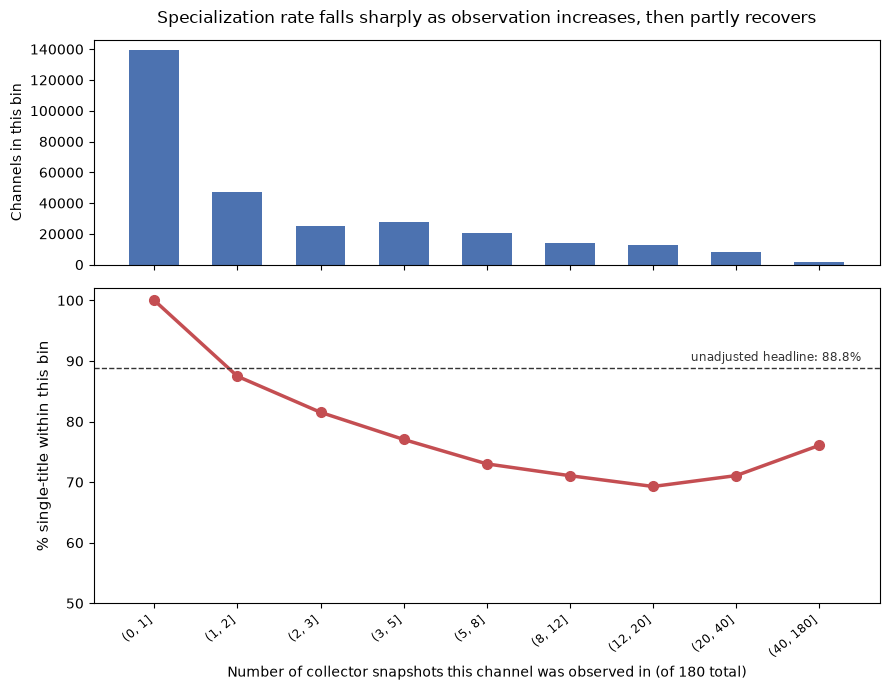

In [8]:
# Two stacked panels sharing one x-axis, not a dual-axis overlay -- same
# two series (bin population, bin specialization rate), each on its own
# proper scale.
x_labels = [str(b) for b in exposure_grp.index]
x_pos = range(len(exposure_grp))

fig, (ax_pop, ax_rate) = plt.subplots(2, 1, figsize=(9, 7), sharex=True, height_ratios=[1, 1.4])

ax_pop.bar(x_pos, exposure_grp["n_channels"], color="#4C72B0", width=0.6)
ax_pop.set_ylabel("Channels in this bin", fontsize=10)
ax_pop.set_title("Specialization rate falls sharply as observation increases, then partly recovers", fontsize=12, pad=12)

ax_rate.plot(x_pos, exposure_grp["pct_single"], color="#C44E52", linewidth=2.5, marker="o", markersize=7)
ax_rate.axhline(pct_single, color="#333333", linewidth=1, linestyle="--")
ax_rate.text(len(exposure_grp) - 0.5, pct_single + 1.2, f"unadjusted headline: {pct_single:.1f}%", fontsize=8.5, ha="right", color="#333333")
ax_rate.set_ylabel("% single-title within this bin", fontsize=10.5)
ax_rate.set_ylim(50, 102)
ax_rate.set_xticks(x_pos)
ax_rate.set_xticklabels(x_labels, rotation=40, ha="right", fontsize=8.5)
ax_rate.set_xlabel(f"Number of collector snapshots this channel was observed in (of {n_snapshot_dates} total)", fontsize=10)

plt.tight_layout()
plt.savefig(Path.cwd() / "_specialization_fig2_exposure_confound.png", dpi=200, bbox_inches="tight")
plt.show()

### Read -- 89% is a real but inflated number; ~69-77% is the more defensible headline

**Updated 2026-10-02 (5-week window, 180 snapshots, up from 3 weeks/120 snapshots) -- and a real bug was caught on this re-run, not just numbers refreshed.** The exposure bins below were hardcoded with a top edge of 120, matching the collector's snapshot count at the time this notebook was first written. With the collector now at 180 snapshots, that hardcoded edge was silently dropping every channel observed more than 120 times into an uncounted bin (74 channels this run) -- exactly the highest-exposure population this section's own "recovery at the high end" claim depends on. Fixed to use the live snapshot count instead of a literal 120, so this doesn't silently break again as the collector keeps running.

**The confound is still real, not a false alarm.** `n_snapshots` (how many of the project's 180 total collector polls caught a channel at all) correlates with `n_titles` (distinct titles observed) at Spearman rho=0.369 (was 0.343), essentially certain not to be chance. Specialization rate still falls from 100% (channels caught in exactly one snapshot) down to a floor, then partly recovers at the very top end -- same shape as before, but the floor is now **lower** and the recovery **weaker**: floor ~69.3% (channels caught 12-20 times, was ~74% at 8-20 times) recovering to ~76.1% at 40+ snapshots (was ~84%).

**This directly contradicts this section's own prediction from the previous run** ("re-running this notebook in a month is expected to narrow, not just repeat, this range"). It did not narrow -- it widened, and shifted down. More data did not resolve the exposure confound the way more data resolved, say, the League/Teamfight Tactics chance-adjustment question in `creator_crossover.ipynb`. Worth stating plainly rather than quietly revising the prediction away: this specific confound does not obviously self-correct just by running the collector longer, at least not over this five-week horizon. A real possibility worth checking later: the weaker top-end recovery may reflect a genuinely different, growing population of high-frequency multi-title channels (co-stream/variety orgs) showing up more now that there's more time for them to accumulate exposure -- not yet checked directly.

**Revised headline: specialization is real and still the dominant pattern, but closer to 69-77% than to 89%.** 62.9% of the tracked population (186,411 of 296,583 channels) has been observed in 2 or fewer snapshots (was 65% of 233,540) -- the median channel has still only been seen twice -- and that low-exposure majority is exactly what pulls the unadjusted 88.8% (was 90.3%) up. The 69-77% range (from the moderate-exposure bins, where the estimate stabilizes) is the more defensible number to cite as this project's actual estimate of the underlying rate, not 88.8% cited flat and not the previous run's 74-80% either.

**What doesn't change**: even at the low end of this range, a clear majority of creators specialize in one title. The core Post 3 claim -- title itself, not genre or platform, is the primary boundary most creators' behavior respects -- survives this check, and in fact the null-model test's own specialization read (`creator_crossover_null_model_test.ipynb`, 88.8% unadjusted) is now in exact agreement with this notebook's own unadjusted figure, which wasn't true to the same precision before. What changes is the confidence interval around the number, and the discipline of citing "roughly 69-77%, with a wide and structured confound around observation length" rather than a single unqualified 89% -- or the previous run's 74-80%, which this run shows was itself not yet stable.

**On whether this will keep improving**: the previous run predicted it would; it didn't, over this horizon. The honest position now is that this confound's behavior over time is itself an open, not-yet-resolved question -- worth checking again at a meaningfully longer horizon (months, not weeks) before assuming either "it stabilizes" or "it keeps drifting" is the right model.